In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,accuracy_score
import seaborn as sns

In [4]:
df = pd.DataFrame({'Player':['Reetam']*8,'Opponent':['Aman','Vivek','jay','raj','lo','po','so','jo'],'PlayerScore':
                  [11,26,4,5,6,7,12,13],'OpponentScore':[10,27,5,6,5,8,11,18],'Tournament':['state','state','open','open',
                'Inter-IIT','Inter-IIT','National','National'],'Result':['win','loss','loss','loss','win','loss','win','loss']})

In [7]:
df.to_csv("C://Users/User/Downloads/tt.csv")

In [10]:
df = pd.read_csv("C://Users/User/Downloads/tt.csv")

In [11]:
df.head()

,Player,Opponent,PlayerScore,OpponentScore,Tournament,Result
0,Reetam,Aman,11,10,state,win
1,Reetam,Vivek,26,27,state,loss
2,Reetam,jay,4,5,open,loss
3,Reetam,raj,5,6,open,loss
4,Reetam,lo,6,5,Inter-IIT,win


In [12]:
matches = len(df)
print("Total Matches", matches )

Total Matches 8


In [15]:
wins = len(df[df['Result'] == 'win'])
losses = len(df[df['Result'] == 'loss'])

In [16]:
print(wins,losses)

3 5


In [17]:
print("Wins:", wins)
print("Losses:", losses)


Wins: 3
Losses: 5


In [18]:
win_p = (wins/matches)*100

In [19]:
win_p

37.5

In [21]:
print(f"Win Percentage: {win_p:.2f}%")

Win Percentage: 37.50%


In [22]:
avg_score = df['PlayerScore'].mean()

In [23]:
print(f"Average Player Score: {avg_score:.2f}")

Average Player Score: 10.50


In [25]:
wins_by_tournament = df[df['Result'] == 'win'].groupby('Tournament').size()

In [26]:
print(wins_by_tournament)

Tournament
Inter-IIT    1
National     1
state        1
dtype: int64


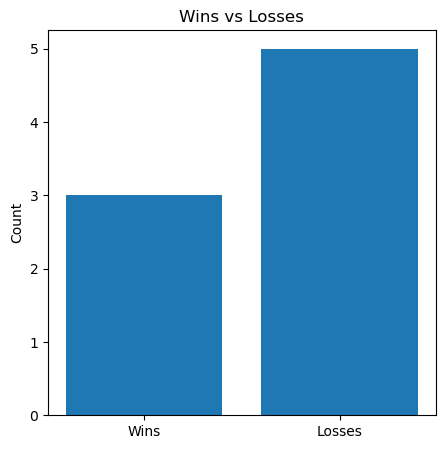

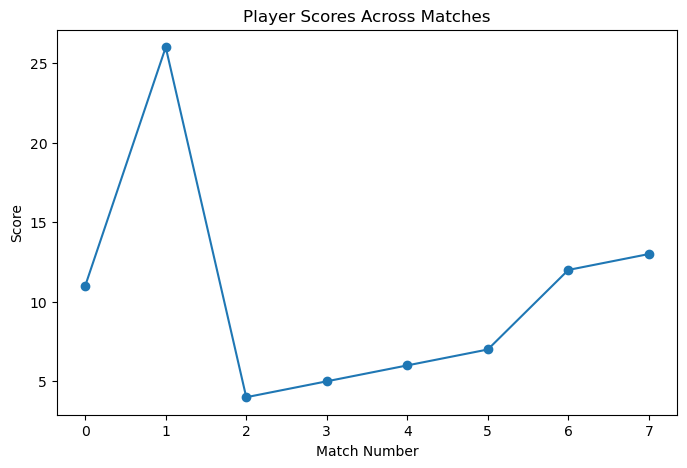

In [27]:
plt.figure(figsize=(5,5))
plt.bar(['Wins', 'Losses'], [wins, losses])
plt.title('Wins vs Losses')
plt.ylabel('Count')
plt.show()

# Visualization 2 — Scores per Match
plt.figure(figsize=(8,5))
plt.plot(df['PlayerScore'], marker='o')
plt.title('Player Scores Across Matches')
plt.xlabel('Match Number')
plt.ylabel('Score')
plt.show()

In [31]:
df['ResultNumeric'] = df['Result'].map({'win': 1, 'loss': 0})

In [32]:
df.head()

,Player,Opponent,PlayerScore,OpponentScore,Tournament,Result,ResultNumeric
0,Reetam,Aman,11,10,state,win,1
1,Reetam,Vivek,26,27,state,loss,0
2,Reetam,jay,4,5,open,loss,0
3,Reetam,raj,5,6,open,loss,0
4,Reetam,lo,6,5,Inter-IIT,win,1


In [33]:
X = df[['PlayerScore','OpponentScore']]

In [34]:
y = df['ResultNumeric']


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.00      0.00      0.00         0

    accuracy                           0.50         2
   macro avg       0.50      0.25      0.33         2
weighted avg       1.00      0.50      0.67         2



C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\User\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [37]:
print(predictions)

[0 1]


In [40]:
print(accuracy_score(y_test,predictions))

0.5


In [42]:
numeric_data = df[['PlayerScore',
                   'OpponentScore'
                  ]]


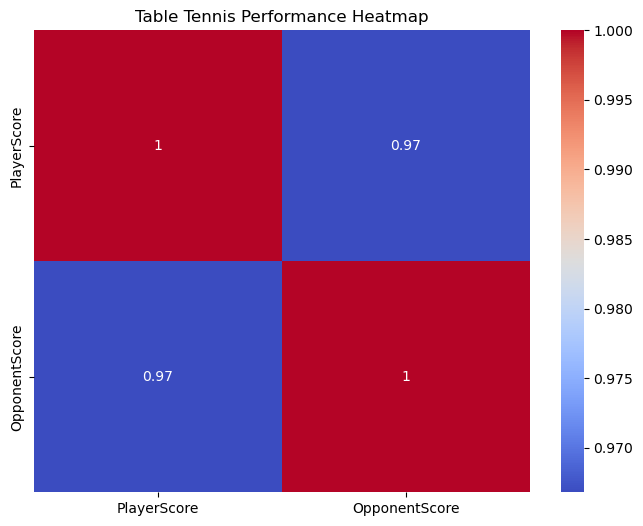

In [44]:
correlation = numeric_data.corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title('Table Tennis Performance Heatmap')
plt.show()